# Treinamento YOLOv8 - Instrumentos Cirúrgicos

**Dataset Combinado:**
- COVOICE19 Surgical Tools
- Surgical Tools alternativo
- **Total: ~6-10k imagens**

**Modelo:** YOLOv8s  
**GPU:** T4 (Runtime → Change runtime type → T4 GPU)

## 1. Instalação

In [1]:
!pip install -q -U pip setuptools wheel
!pip install -q --prefer-binary "numpy>=1.26,<2.3"
!pip install -q --prefer-binary ultralytics roboflow pyyaml

from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
Mounted at /content/drive


## 2. Download Dataset 1 (COVOICE19)

In [2]:
from roboflow import Roboflow
from pathlib import Path

# Substituir API key do Roboflow
rf = Roboflow(api_key="BOr7518ZsqVWxnoVTNub")

project1 = rf.workspace("covoice19-workspace").project("surgical-tools-s93bt")
dataset1 = project1.version(1).download("yolov8", location="dataset1_covoice")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset1_covoice in yolov8:: 100%|██████████| 24128/24128 [00:03<00:00, 6394.89it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Download Dataset 2 (surgical-tools-qygsn)

In [3]:
project2 = rf.workspace("surgical-tools-qygsn").project("surgical-tools-bj0au")
dataset2 = project2.version(1).download("yolov8", location="dataset2_surgical")
dataset2_info = "surgical-tools-qygsn (3k imagens)"

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dataset2_surgical in yolov8:: 100%|██████████| 6020/6020 [00:01<00:00, 4178.48it/s]


## 4. Combinar Datasets

In [4]:
import yaml
import shutil
from pathlib import Path

# Criar estrutura
combined_dir = Path("combined_surgical_tools")
if combined_dir.exists():
    shutil.rmtree(combined_dir)

for split in ['train', 'valid', 'test']:
    (combined_dir / split / 'images').mkdir(parents=True, exist_ok=True)
    (combined_dir / split / 'labels').mkdir(parents=True, exist_ok=True)

# Ler data.yaml
with open(Path(dataset1.location) / 'data.yaml', 'r') as f:
    data1 = yaml.safe_load(f)

with open(Path(dataset2.location) / 'data.yaml', 'r') as f:
    data2 = yaml.safe_load(f)

# Normalizar classes
def normalize_classes(names_data):
    if isinstance(names_data, dict):
        return names_data
    elif isinstance(names_data, list):
        return {i: name for i, name in enumerate(names_data)}
    else:
        raise ValueError(f"Formato não suportado: {type(names_data)}")

data1_names = normalize_classes(data1['names'])
data2_names = normalize_classes(data2['names'])

# Criar mapeamento unificado
all_classes = []
class_mapping_1 = {}
class_mapping_2 = {}

for idx, class_name in data1_names.items():
    if class_name not in all_classes:
        all_classes.append(class_name)
    class_mapping_1[idx] = all_classes.index(class_name)

for idx, class_name in data2_names.items():
    normalized_name = class_name.lower().replace('_', ' ').replace('-', ' ').strip()

    found = False
    for existing in all_classes:
        existing_norm = existing.lower().replace('_', ' ').replace('-', ' ').strip()
        if normalized_name == existing_norm or normalized_name in existing_norm or existing_norm in normalized_name:
            class_mapping_2[idx] = all_classes.index(existing)
            found = True
            break

    if not found:
        all_classes.append(class_name)
        class_mapping_2[idx] = len(all_classes) - 1

# Copiar e remapear
def copy_and_remap(source_dir, dest_dir, class_mapping, prefix):
    stats = {'images': 0, 'labels': 0, 'annotations': 0}

    for split in ['train', 'valid', 'test']:
        src_img = Path(source_dir) / split / 'images'
        src_lbl = Path(source_dir) / split / 'labels'

        if not src_img.exists():
            continue

        for img_file in src_img.glob('*'):
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                new_name = f"{prefix}_{img_file.name}"
                shutil.copy2(img_file, dest_dir / split / 'images' / new_name)
                stats['images'] += 1

        if src_lbl.exists():
            for lbl_file in src_lbl.glob('*.txt'):
                new_name = f"{prefix}_{lbl_file.name}"
                dest_file = dest_dir / split / 'labels' / new_name

                with open(lbl_file, 'r') as f:
                    lines = f.readlines()

                new_lines = []
                for line in lines:
                    parts = line.strip().split()
                    if parts:
                        old_class = int(parts[0])
                        new_class = class_mapping.get(old_class, old_class)
                        parts[0] = str(new_class)
                        new_lines.append(' '.join(parts) + '\n')
                        stats['annotations'] += 1

                with open(dest_file, 'w') as f:
                    f.writelines(new_lines)
                stats['labels'] += 1

    return stats

stats1 = copy_and_remap(dataset1.location, combined_dir, class_mapping_1, "ds1")
stats2 = copy_and_remap(dataset2.location, combined_dir, class_mapping_2, "ds2")

# Criar data.yaml
combined_data = {
    'path': str(combined_dir.absolute()),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': len(all_classes),
    'names': {i: name for i, name in enumerate(all_classes)}
}

with open(combined_dir / 'data.yaml', 'w') as f:
    yaml.dump(combined_data, f, default_flow_style=False)

print(f"✅ {len(all_classes)} classes | {stats1['images'] + stats2['images']} imagens")

✅ 20 classes | 15062 imagens


## 5. Treinar Modelo

In [5]:
from ultralytics import YOLO
import torch

MODEL = "yolov8s.pt"
EPOCHS = 80
IMAGE_SIZE = 640
BATCH_SIZE = 8
DEVICE = 0 if torch.cuda.is_available() else "cpu"

model = YOLO(MODEL)

results = model.train(
    data=str(combined_dir / "data.yaml"),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    patience=20,
    save=True,
    save_period=5,
    cache=True,
    project='/content/drive/MyDrive/yolo_runs',
    name='surgical_combined',
    verbose=True
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=combined_surgical_tools/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=surgical_combined, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, pe

## 6. Visualizar Resultados

Mounted at /content/drive
surgical_combined


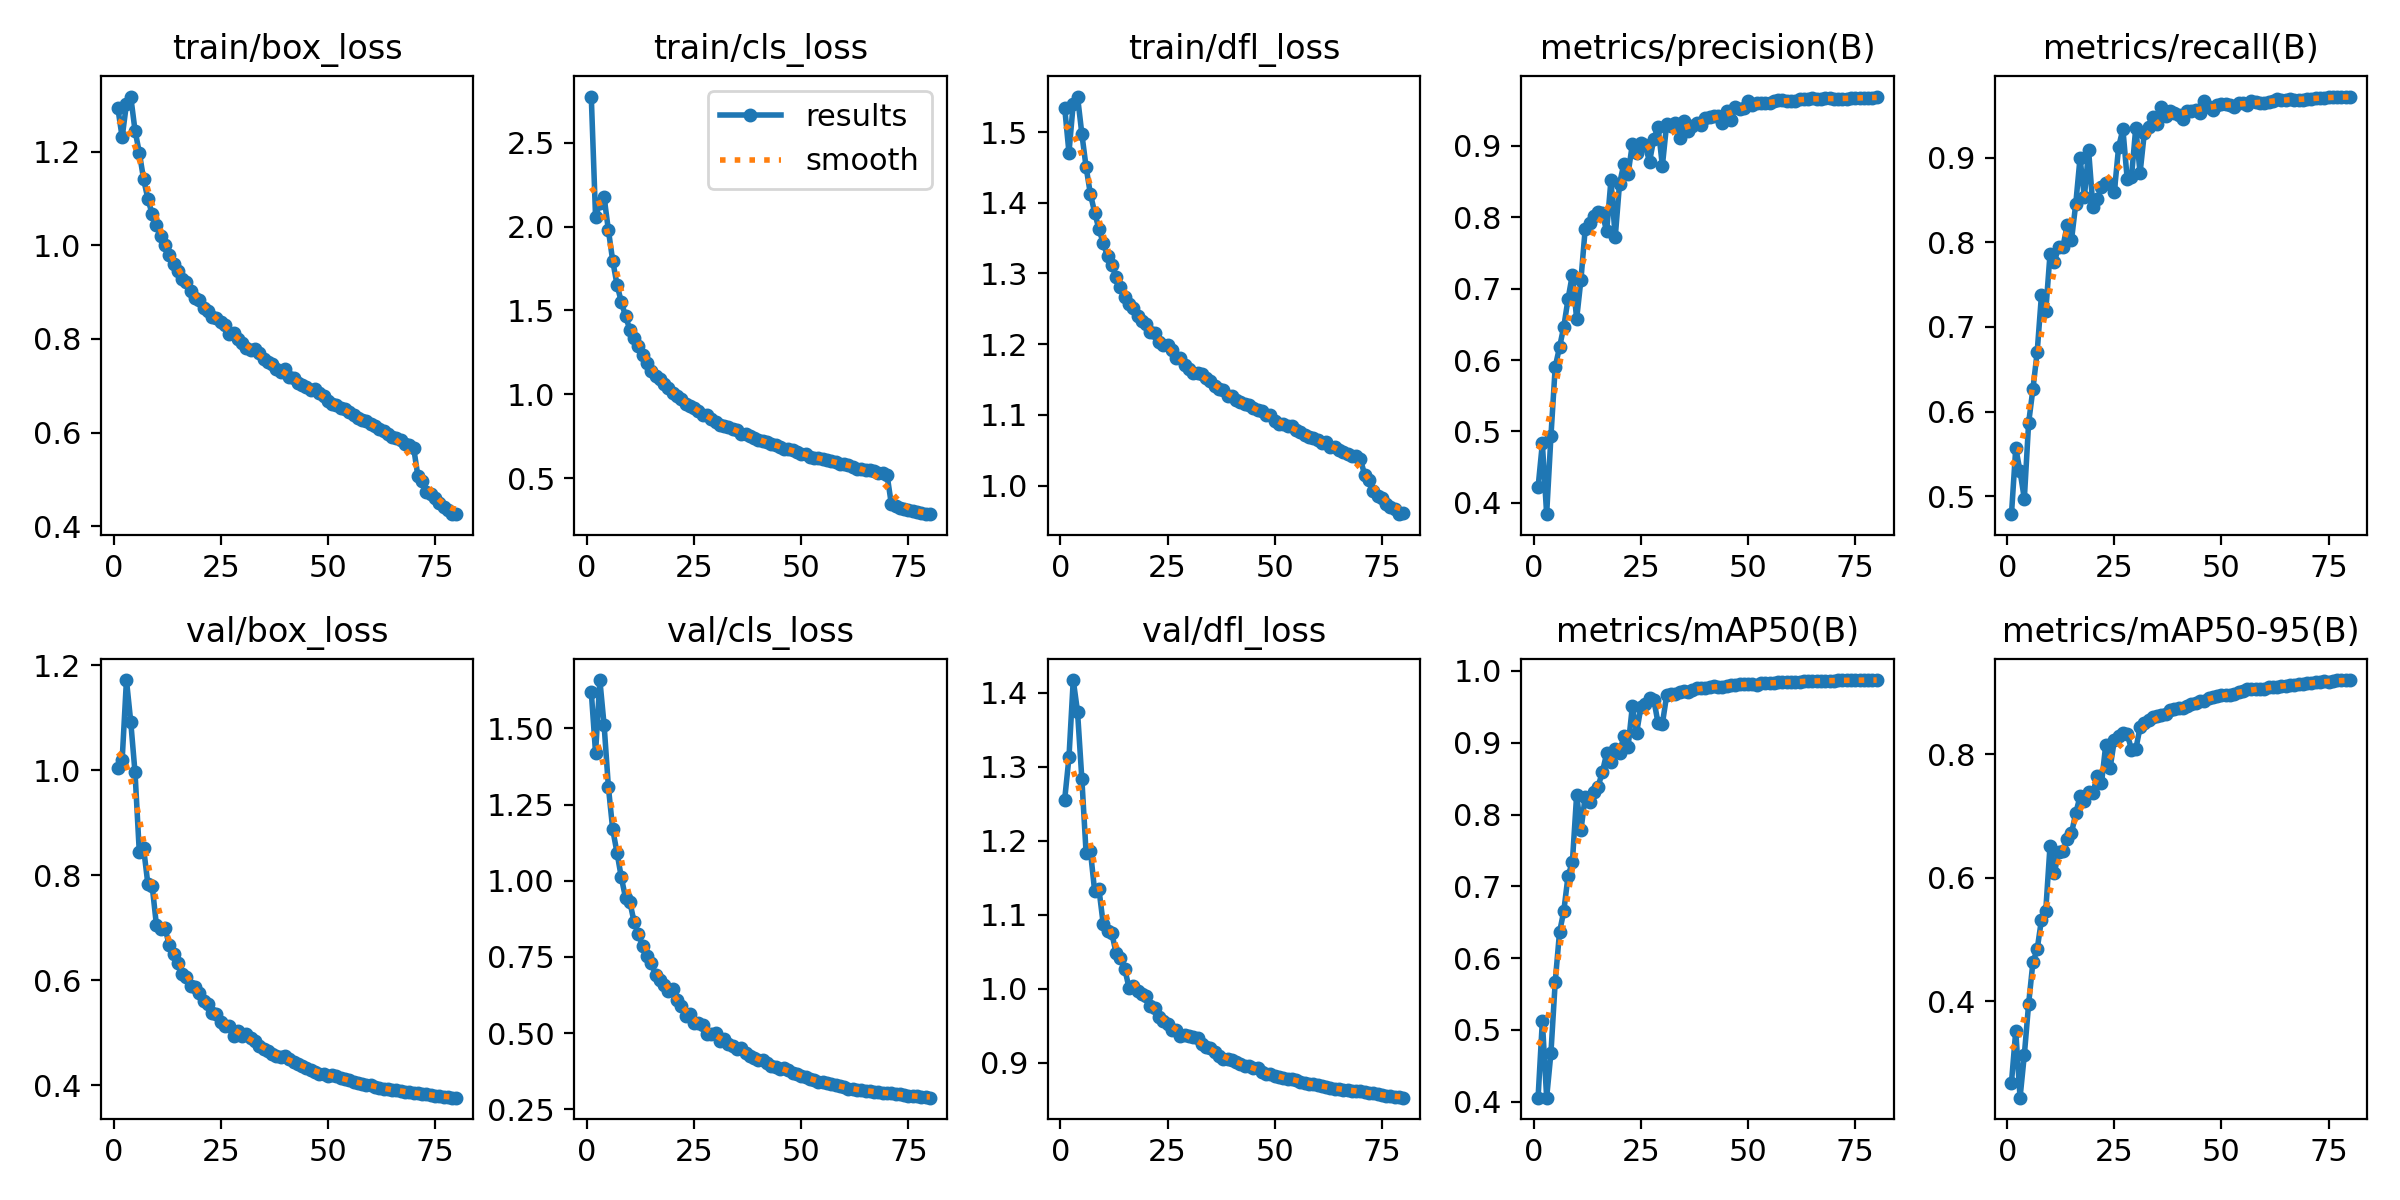

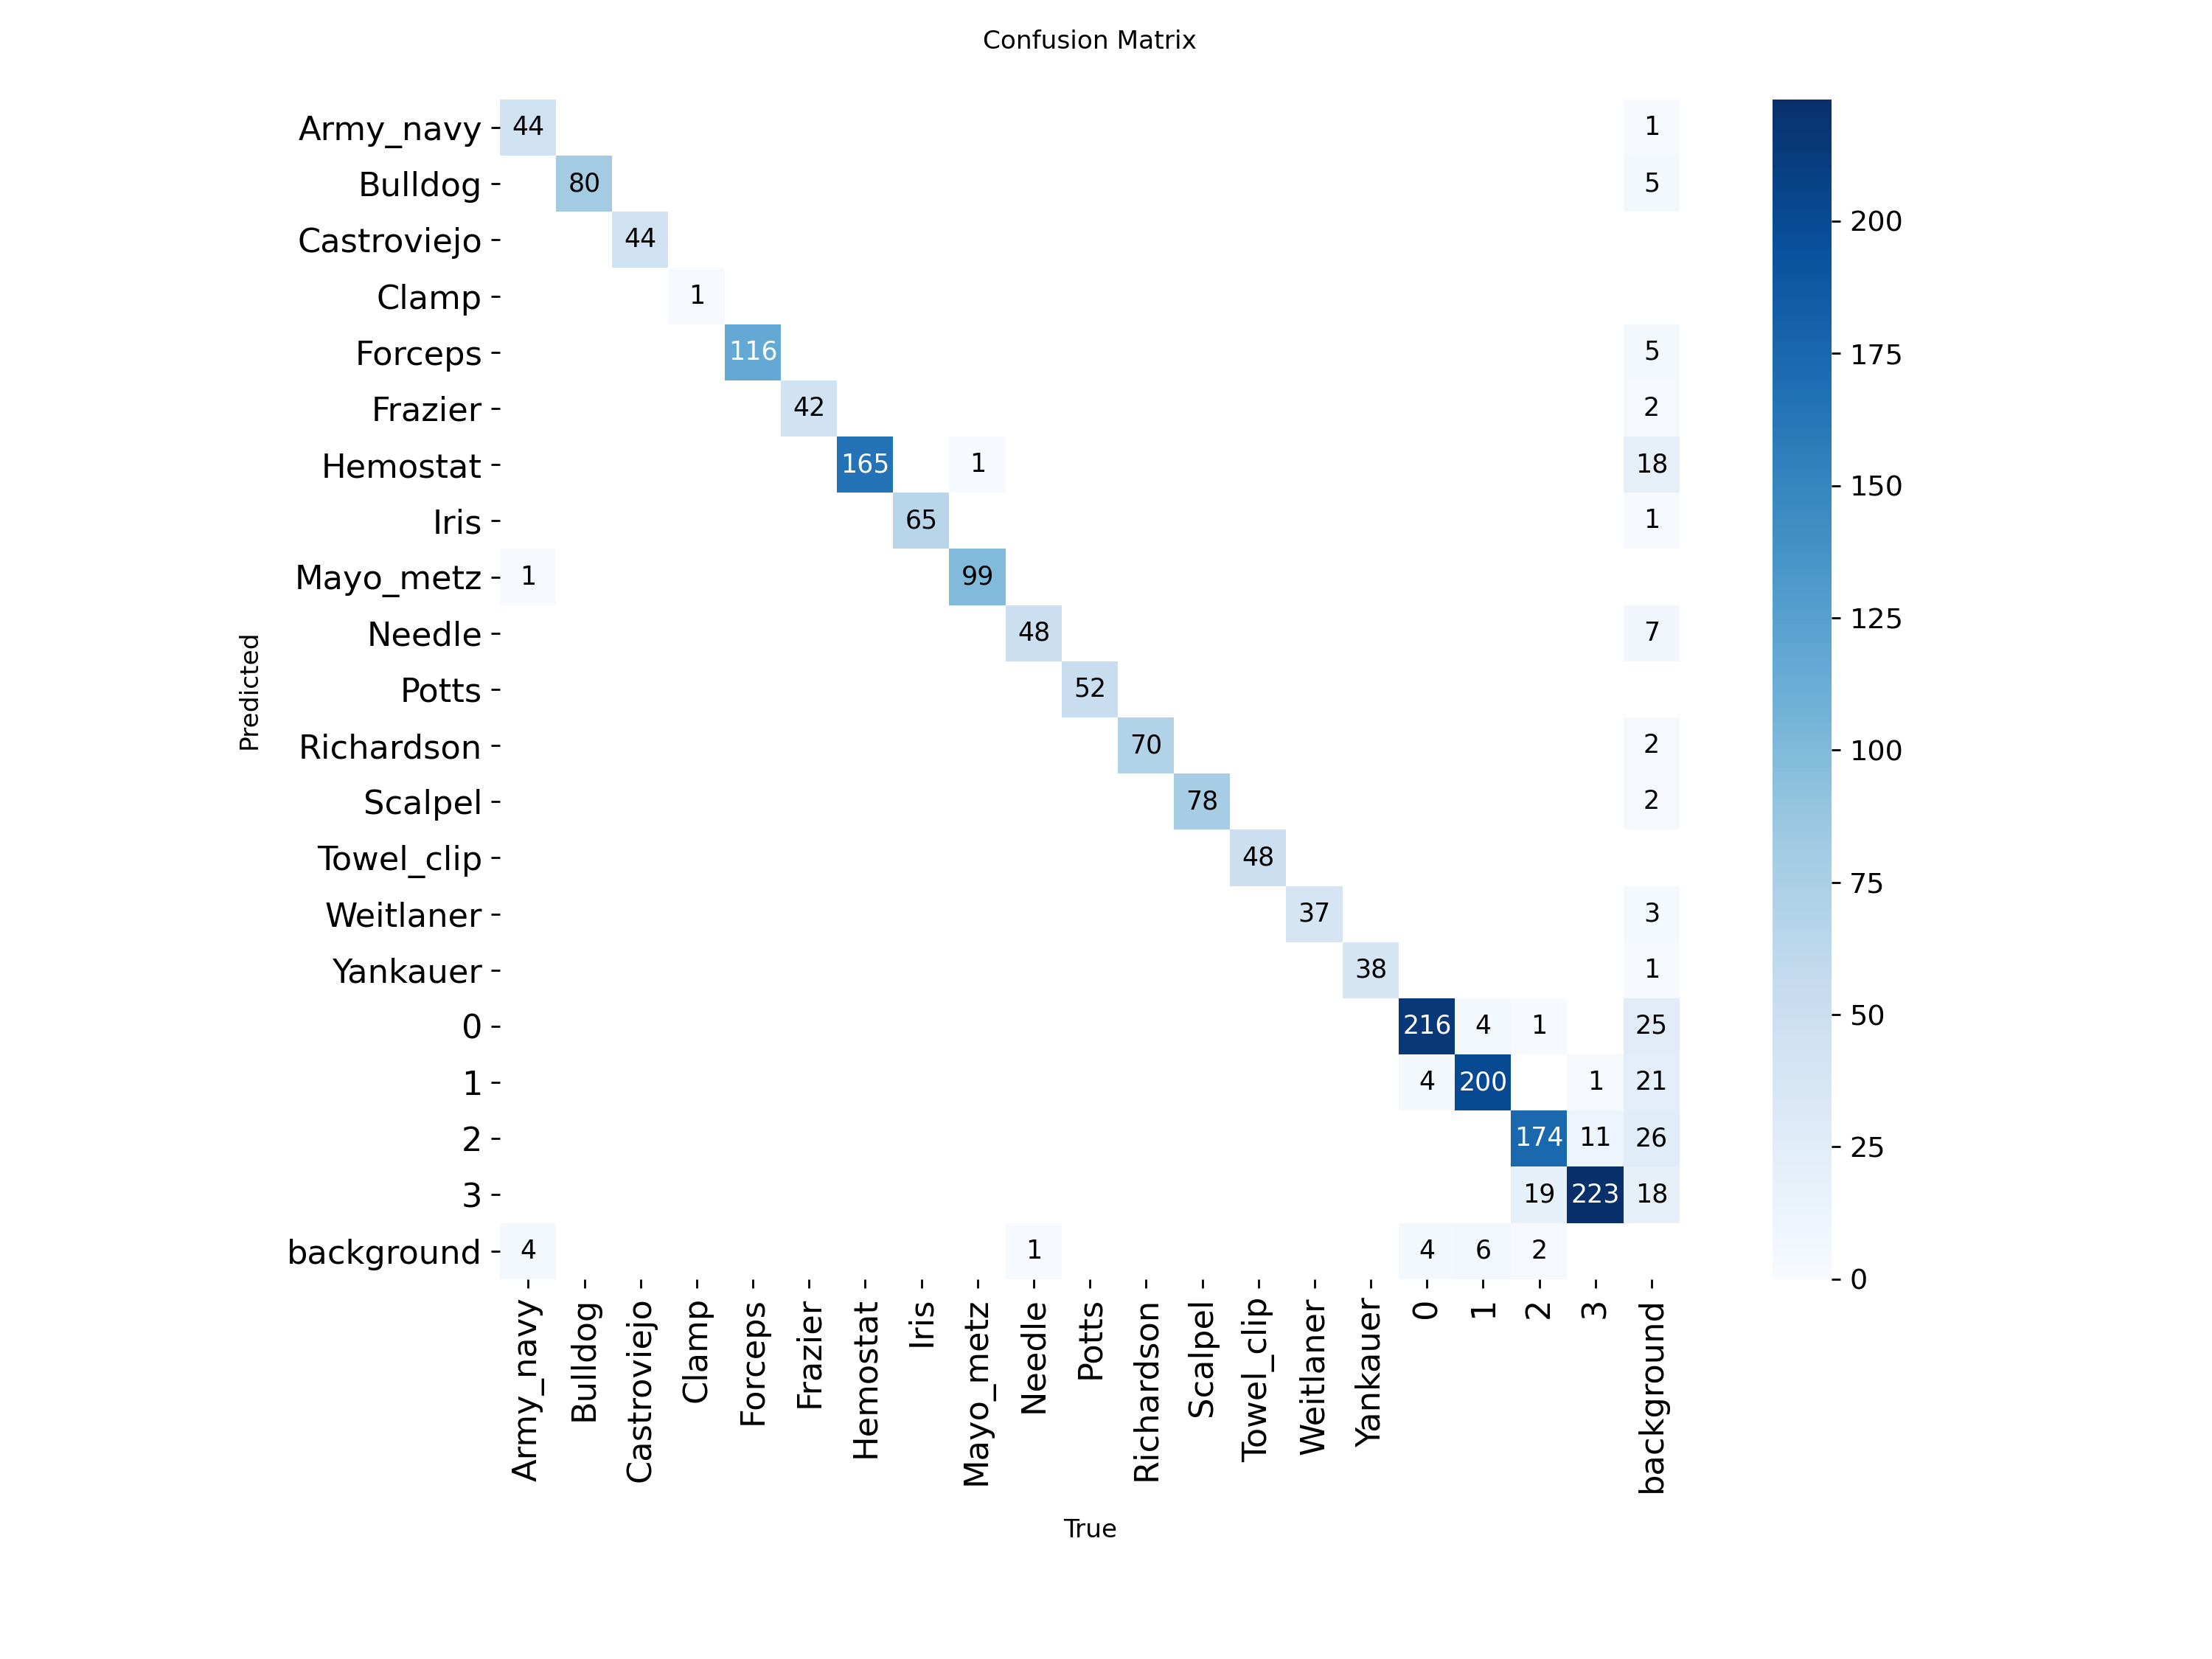

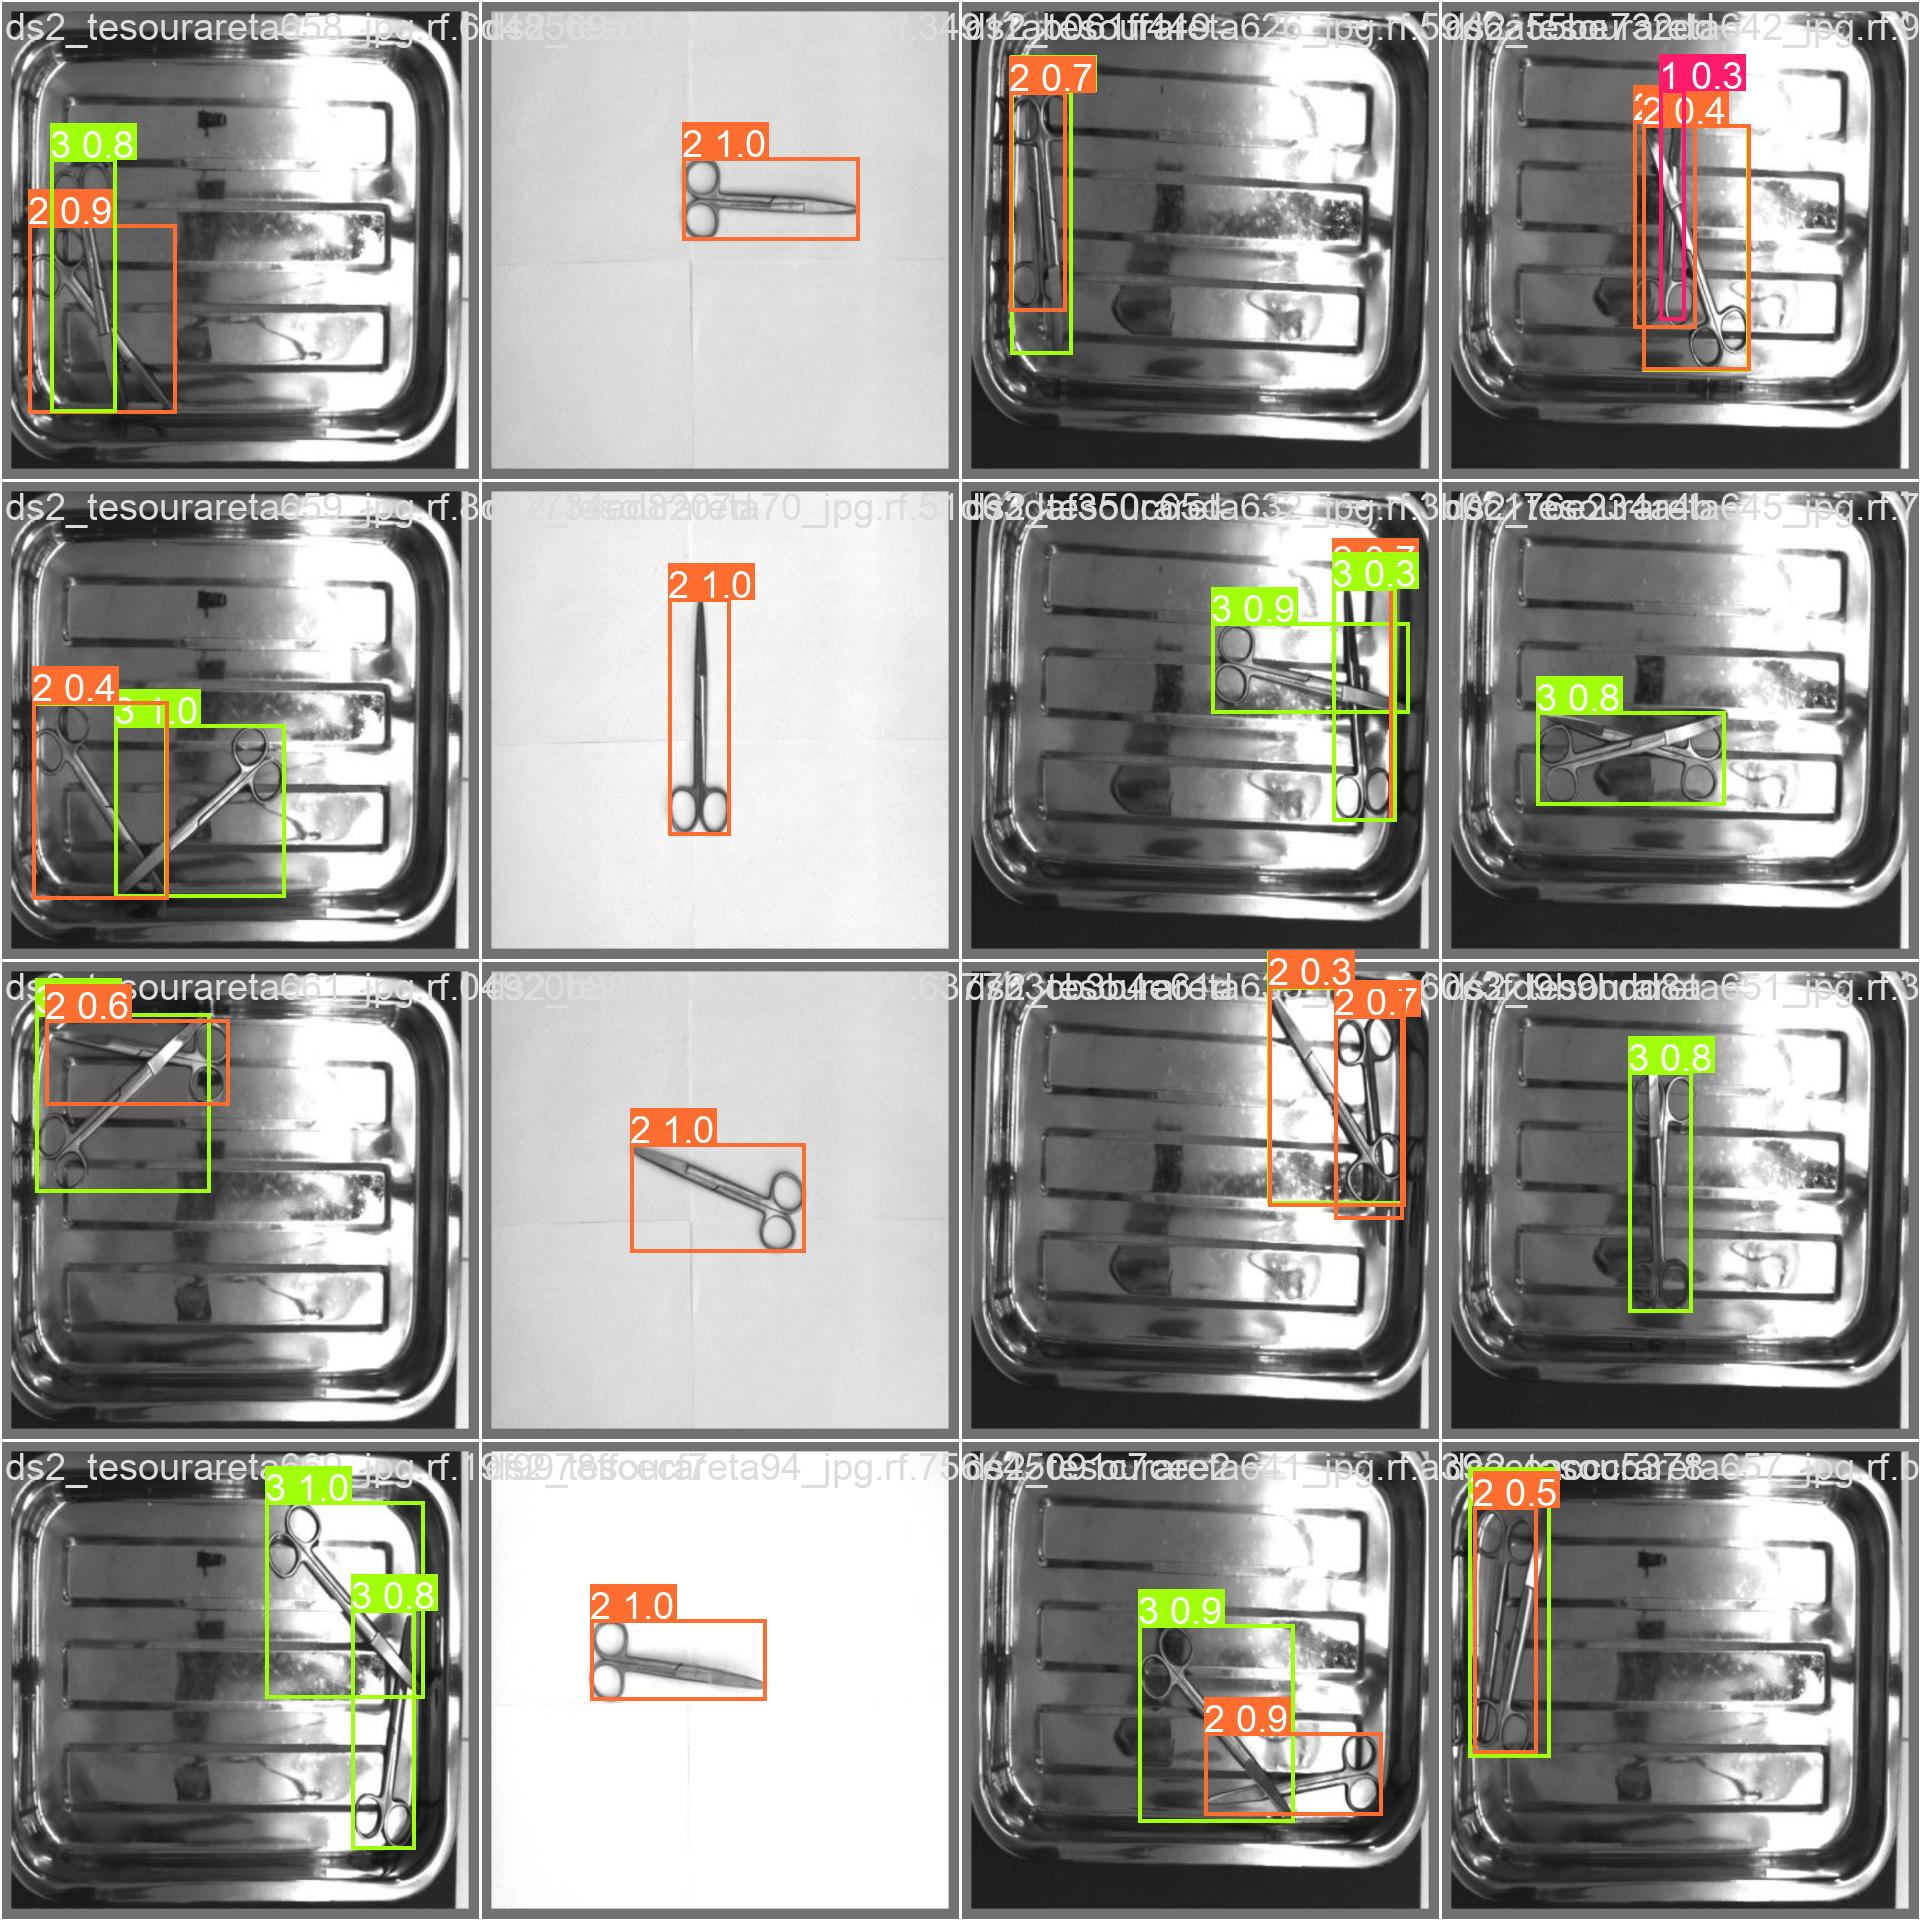

In [3]:
from IPython.display import Image, display
from google.colab import drive
drive.mount('/content/drive')

results_dir = '/content/drive/MyDrive/yolo_runs/surgical_combined'

!ls /content/drive/MyDrive/yolo_runs

display(Image(filename=f'{results_dir}/results.png'))
display(Image(filename=f'{results_dir}/confusion_matrix.png'))
display(Image(filename=f'{results_dir}/val_batch0_pred.jpg'))

## 7. Download do Modelo

In [8]:
from ultralytics import YOLO
from google.colab import files
import shutil
import json

# Caminho do treino
RUN_DIR = '/content/drive/MyDrive/yolo_runs/surgical_combined'

# Carregar modelo treinado
model = YOLO(f'{RUN_DIR}/weights/best.pt')

# Extrair classes direto do modelo
all_classes = list(model.names.values())
print("Classes detectadas:", all_classes)

# Compactar modelo
shutil.make_archive(
    'surgical_combined_model',
    'zip',
    RUN_DIR
)

# Salvar info das classes
class_info = {
    'num_classes': len(all_classes),
    'classes': {i: name for i, name in enumerate(all_classes)}
}

with open('classes_info.json', 'w') as f:
    json.dump(class_info, f, indent=2)

# Download
files.download('surgical_combined_model.zip')
files.download('classes_info.json')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 78.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Classes detectadas: ['Army_navy', 'Bulldog', 'Castroviejo', 'Clamp', 'Forceps', 'Frazier', 'Hemostat', 'Iris', 'Mayo_metz', 'Needle', 'Potts', 'Richardson', 'Scalpel', 'Towel_clip', 'Weitlaner', 'Yankauer', '0', '1', '2', '3']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>